# Section 1: EDA (Exploratory Data Analysis)

In this part of the project we'll be learning the following using univariate, bivariate, multivariate analysis:

1. Load and Inspect Data
2. Univariate analysis: distributions of each lyrical feature, genre breakdown, release date spread
2. Bivariate analysis: correlation heatmaps, feature-vs-feature scatter plots, genre vs. lyrical features
2. Multivariate analysis: pairplots, grouped comparisons
5. Formulate a hypothesis about what clusters might emerge

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# Style for visuals
PALETTE = sns.color_palette('husl', 10)
plt.style.use('dark_background')

## 1. Load and First Look at Data

In [2]:
df = pd.read_csv('../data/train.csv')

print(df.shape) # 24 columns, 28362 rows
df.head()

(28362, 24)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

In [4]:
df.describe()

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,42948.166878,1990.239652,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,24747.811462,18.486997,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,0.000000,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,20393.500000,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,45407.000000,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,64089.500000,2007.000000,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,82451.000000,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


In [5]:
df.isnull().sum()

Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

**Initial Thoughts:**
- We have 28,362 song and 24 columns
- No missing values and no duplicated rows
- `Unnamed: 0` column doesn't have enough info to be interpretable, the numbers could be for indexing or could mean anything
- `release_date` is from 1950-2019
- `age` feature is just a different version of `release_date`, may be better to drop for our model

## 2. Univariate Analysis

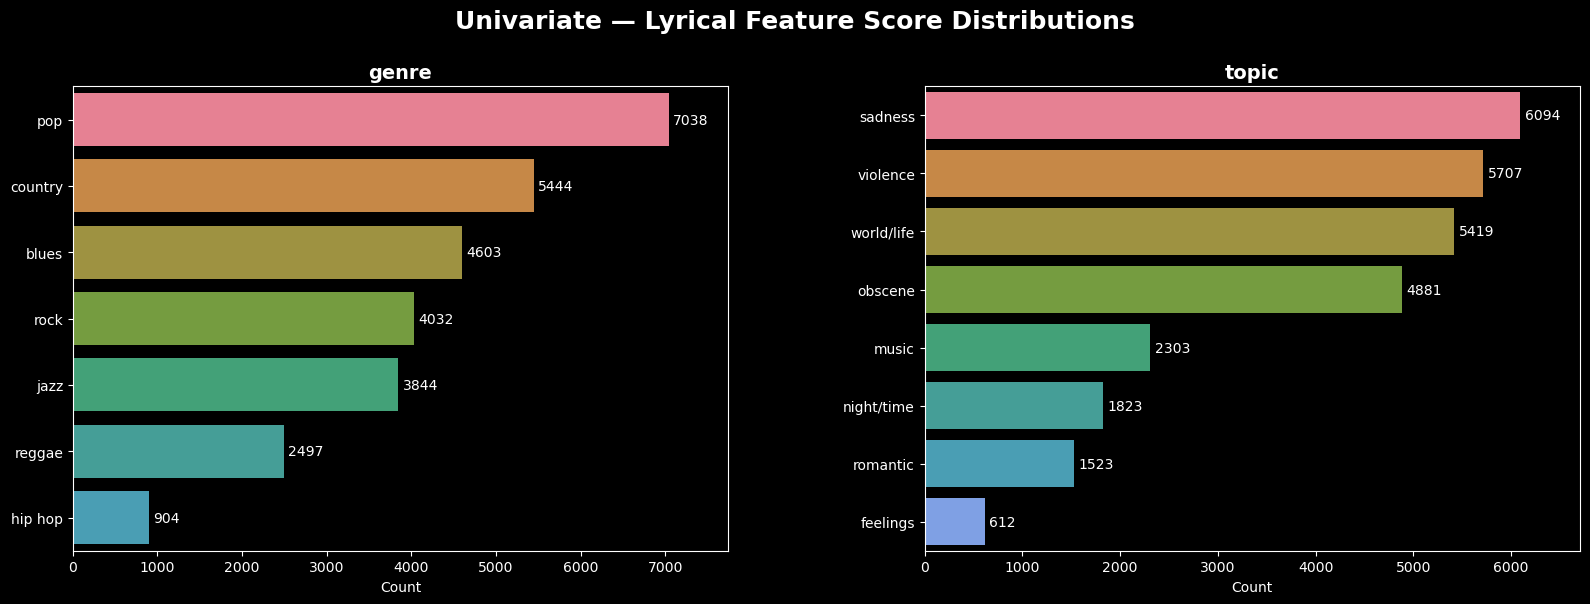

In [41]:
# see how much each lyrical topic and genre is represented in the dataset
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax = ax.flatten()

for i, col in enumerate(['genre', 'topic']):
    counts = df[col].value_counts() # already returns in descending order
    sns.barplot(x=counts.values, y=counts.index, ax=ax[i], hue=counts.index, 
                palette=PALETTE[:len(counts)], edgecolor=None, orient='h')
    
    ax[i].set_title(f"{col}", fontsize=14, fontweight="bold")
    ax[i].set_xlabel("Count")
    ax[i].set_ylabel("")

    # Add count labels
    for j, value in enumerate(counts.values):
        ax[i].text(
            value + 50,          # x-position (slightly to the right of bar)
            j,                   # y-position (aligned with bar)
            str(value),          # label text
            va='center',
            fontsize=10
        )
    
    # Add padding to right side of plot
    max_val = counts.values.max()
    ax[i].set_xlim(0, max_val * 1.1)

plt.suptitle("Univariate — Lyrical Feature Score Distributions", y=1, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

- Most dominant `genre`: Pop, Country
- Most dominant `topic`: Sadness, Violence
    - Interesting because it doesn't match the usual upbeat energy of Pop or Country music
- Both plots show imbalance, weighted towards certain genres/topics which may influence when building the model

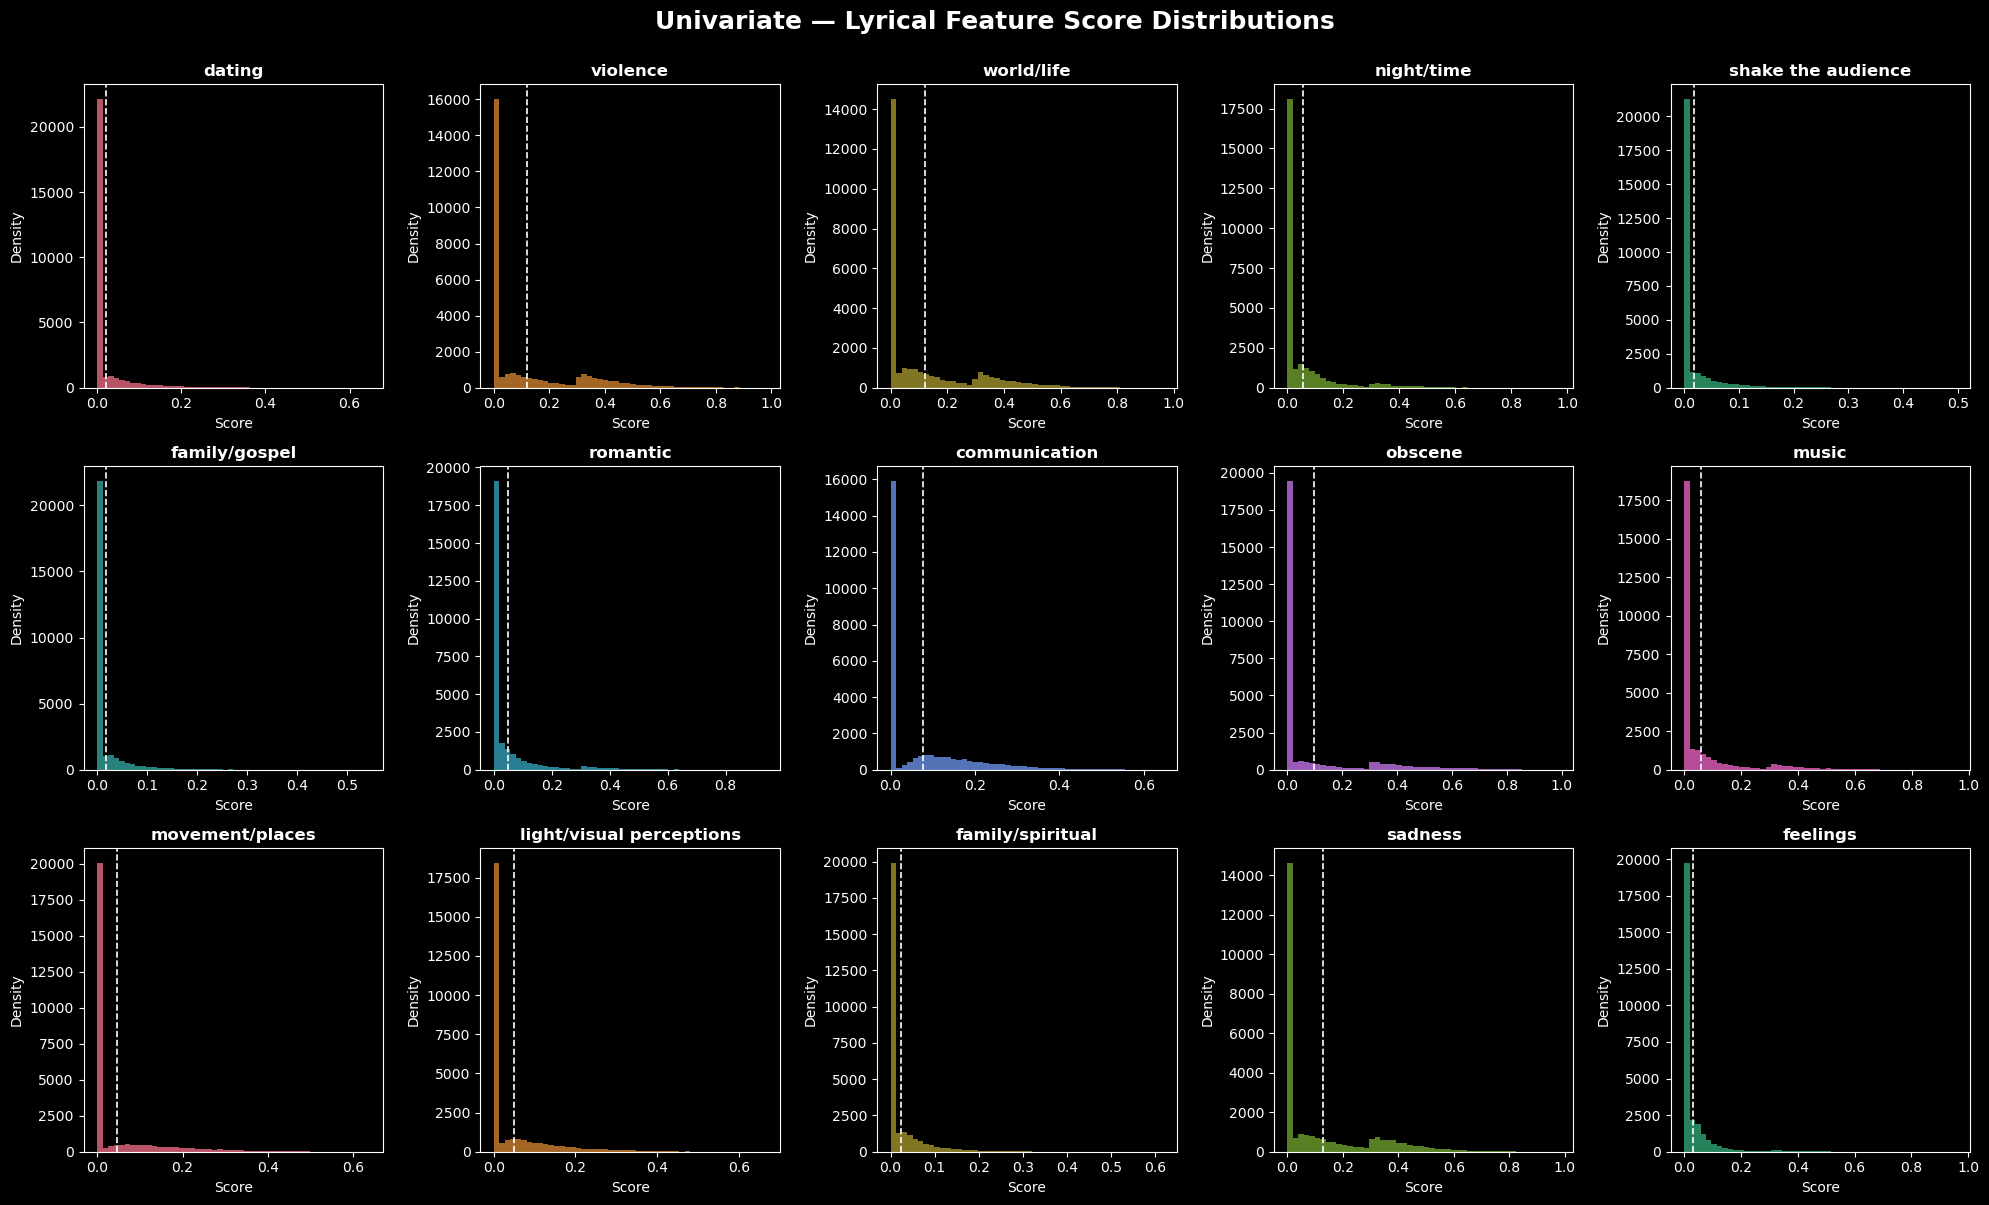

In [42]:
# how likely each song is to express each lyrical theme (from 0-1)

lyrical_cols = [
    'dating', 'violence', 'world/life', 'night/time', 'shake the audience',
    'family/gospel', 'romantic', 'communication', 'obscene', 'music',
    'movement/places', 'light/visual perceptions', 'family/spiritual',
    'sadness', 'feelings'
]

fig, ax = plt.subplots(3, 5, figsize=(20, 12))
ax = ax.flatten()

# iterate through list of lyrical_cols and create histplots
for i, col in enumerate(lyrical_cols):
    sns.histplot(df[col], ax=ax[i], bins=50, color=PALETTE[i % len(PALETTE)], edgecolor=None)
    
    # mean line for each plot
    mean_val = df[col].mean()
    ax[i].axvline(mean_val, linestyle='--', linewidth=1.2, color='white')

    ax[i].set_title(f"{col}", fontweight="bold")
    ax[i].set_xlabel("Score")
    ax[i].set_ylabel("Density")

# hide unused axes 
for j in range(len(lyrical_cols), len(ax)):
    ax[j].set_visible(False)


plt.suptitle("Univariate — Lyrical Feature Score Distributions", y=1, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

The data shows that all lyrical columns are heavily right skewed, this makes sense because songs usually are about one or two dominant themes. For example with `movement/places`, only a small subset of songs have this theme while the rest of the songs that aren't about this specific topic will score near zero.

This also means that features with higher mean scores (represented by the dotted line in our plots) are more commonly present across songs.

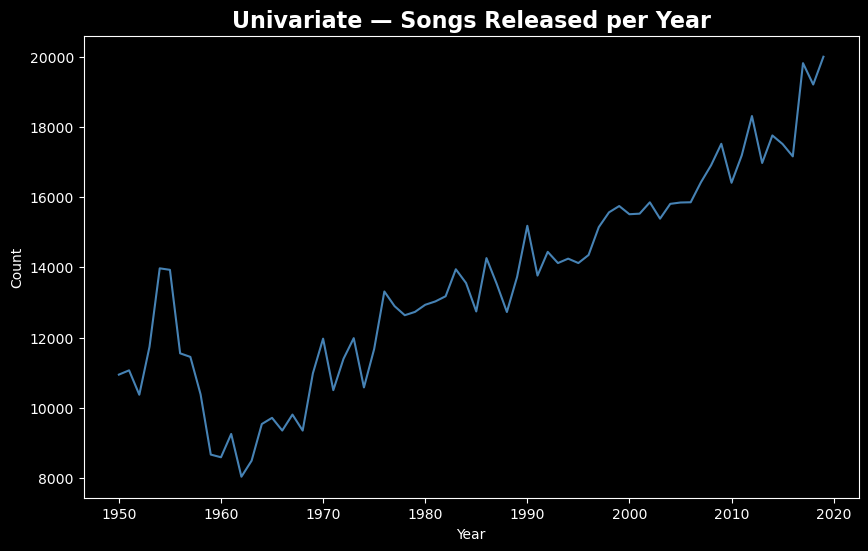

In [10]:
# songs released per year
plt.figure(figsize=(10, 6))

sns.lineplot(x=df['release_date'], color='steelblue', y=df.index, errorbar=None)

plt.title("Univariate — Songs Released per Year", y=1, fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

- Checking the year songs are released, could reveal how songs relates to an era
- 1950s-1980s show fluctuations
- Starting around 1980s, there's a clear upward trend in songs being released each year.
- More slope around 2000s, meaning more rapid growth is music production. Could reflect how tools/streaming/distribution have changed over time, making it easier to create and produce music.
- More weighted towards recent decades.

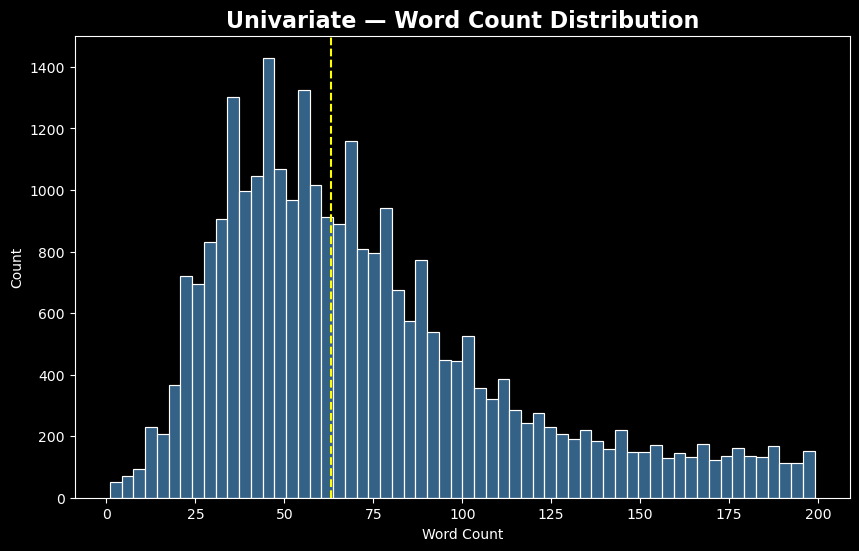

Median Value:  63.0


In [11]:
# lyric word count
plt.figure(figsize=(10, 6))

sns.histplot(df['len'], color='steelblue')

# Median line
median_val = df['len'].median()
plt.axvline(median_val, linestyle='--', linewidth=1.5, color='yellow')

plt.title("Univariate — Word Count Distribution", y=1, fontsize=16, fontweight='bold')
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.show()

print("Median Value: ", median_val)


- Typical song's length is 63 words. 
    - Used median line to show a more honest representation of typical song length than mean because it's more resistant to outliers.
- Skewed to the right, meaning most songs have a typical number of words while others are longer.
- Most songs fall within the range of 25-75 words

## 3. Bivariate Analysis

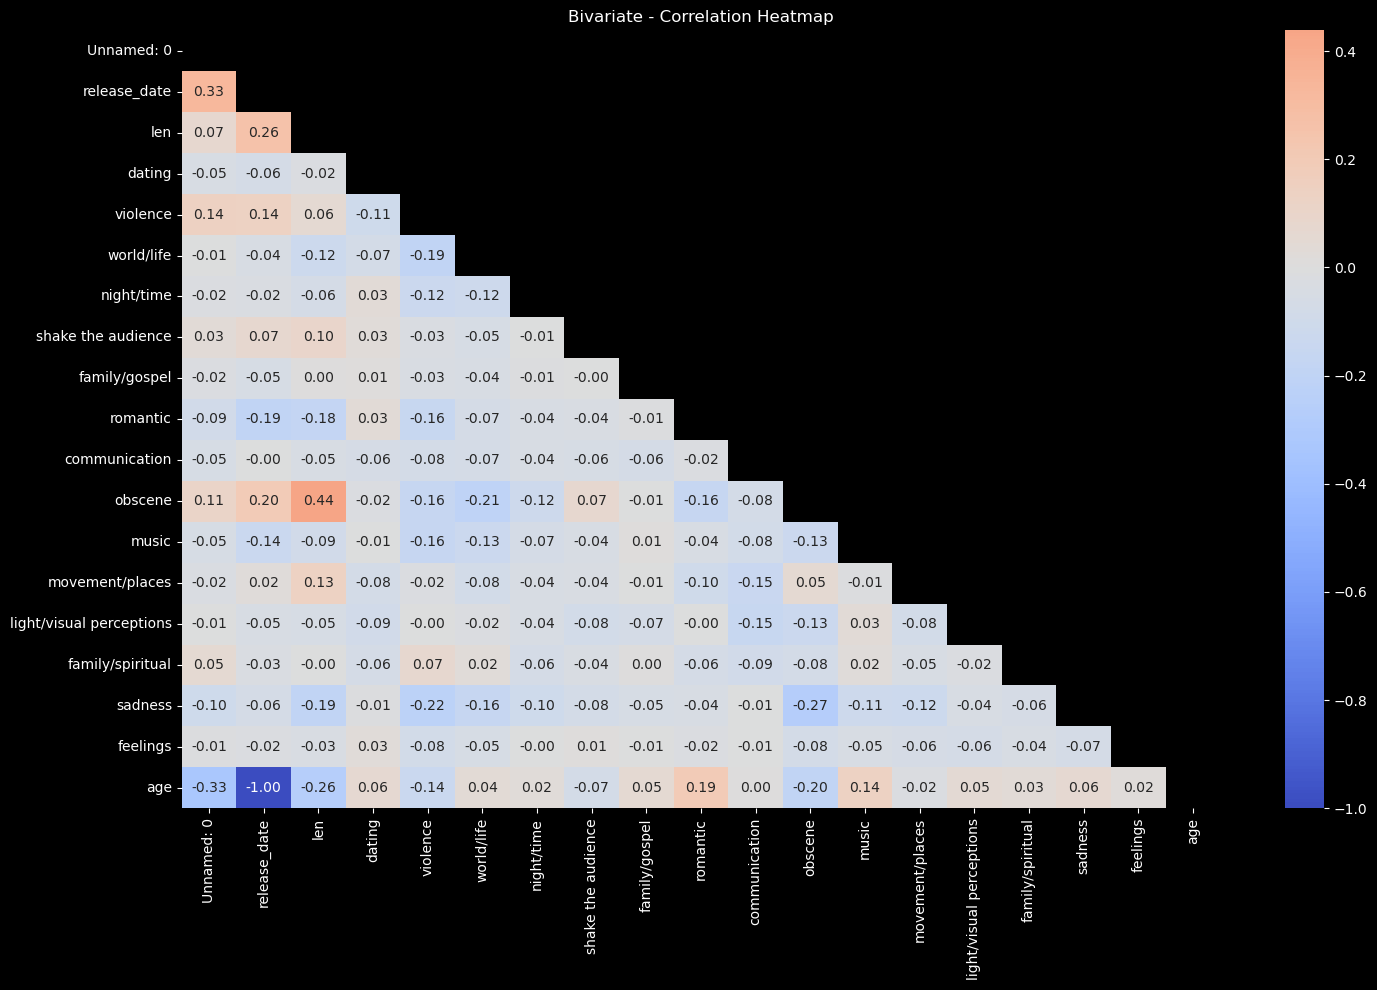

In [43]:
corr_cols = df.drop(columns=['artist_name', 'track_name', 'lyrics', 'genre', 'topic']).columns
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

plt.figure(figsize=(15,10))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Bivariate - Correlation Heatmap')
plt.tight_layout()
plt.show()

- Positive correlation:
    -  `obscene` and `len` = 0.44 (strongest positive correlation - longer songs tend to have more obscene words)
    - `release_date` and `len` = 0.26 (weaker correlation - newer songs tend to be longer)
- Negative correlation:
    - `age` and `release_date` = -1.00 (move together perfectly - multicollinearity)

In [ ]:
# mean lyrical scores per genre
mean_genre_lyrics = df.groupby('genre')[lyrical_cols].mean()


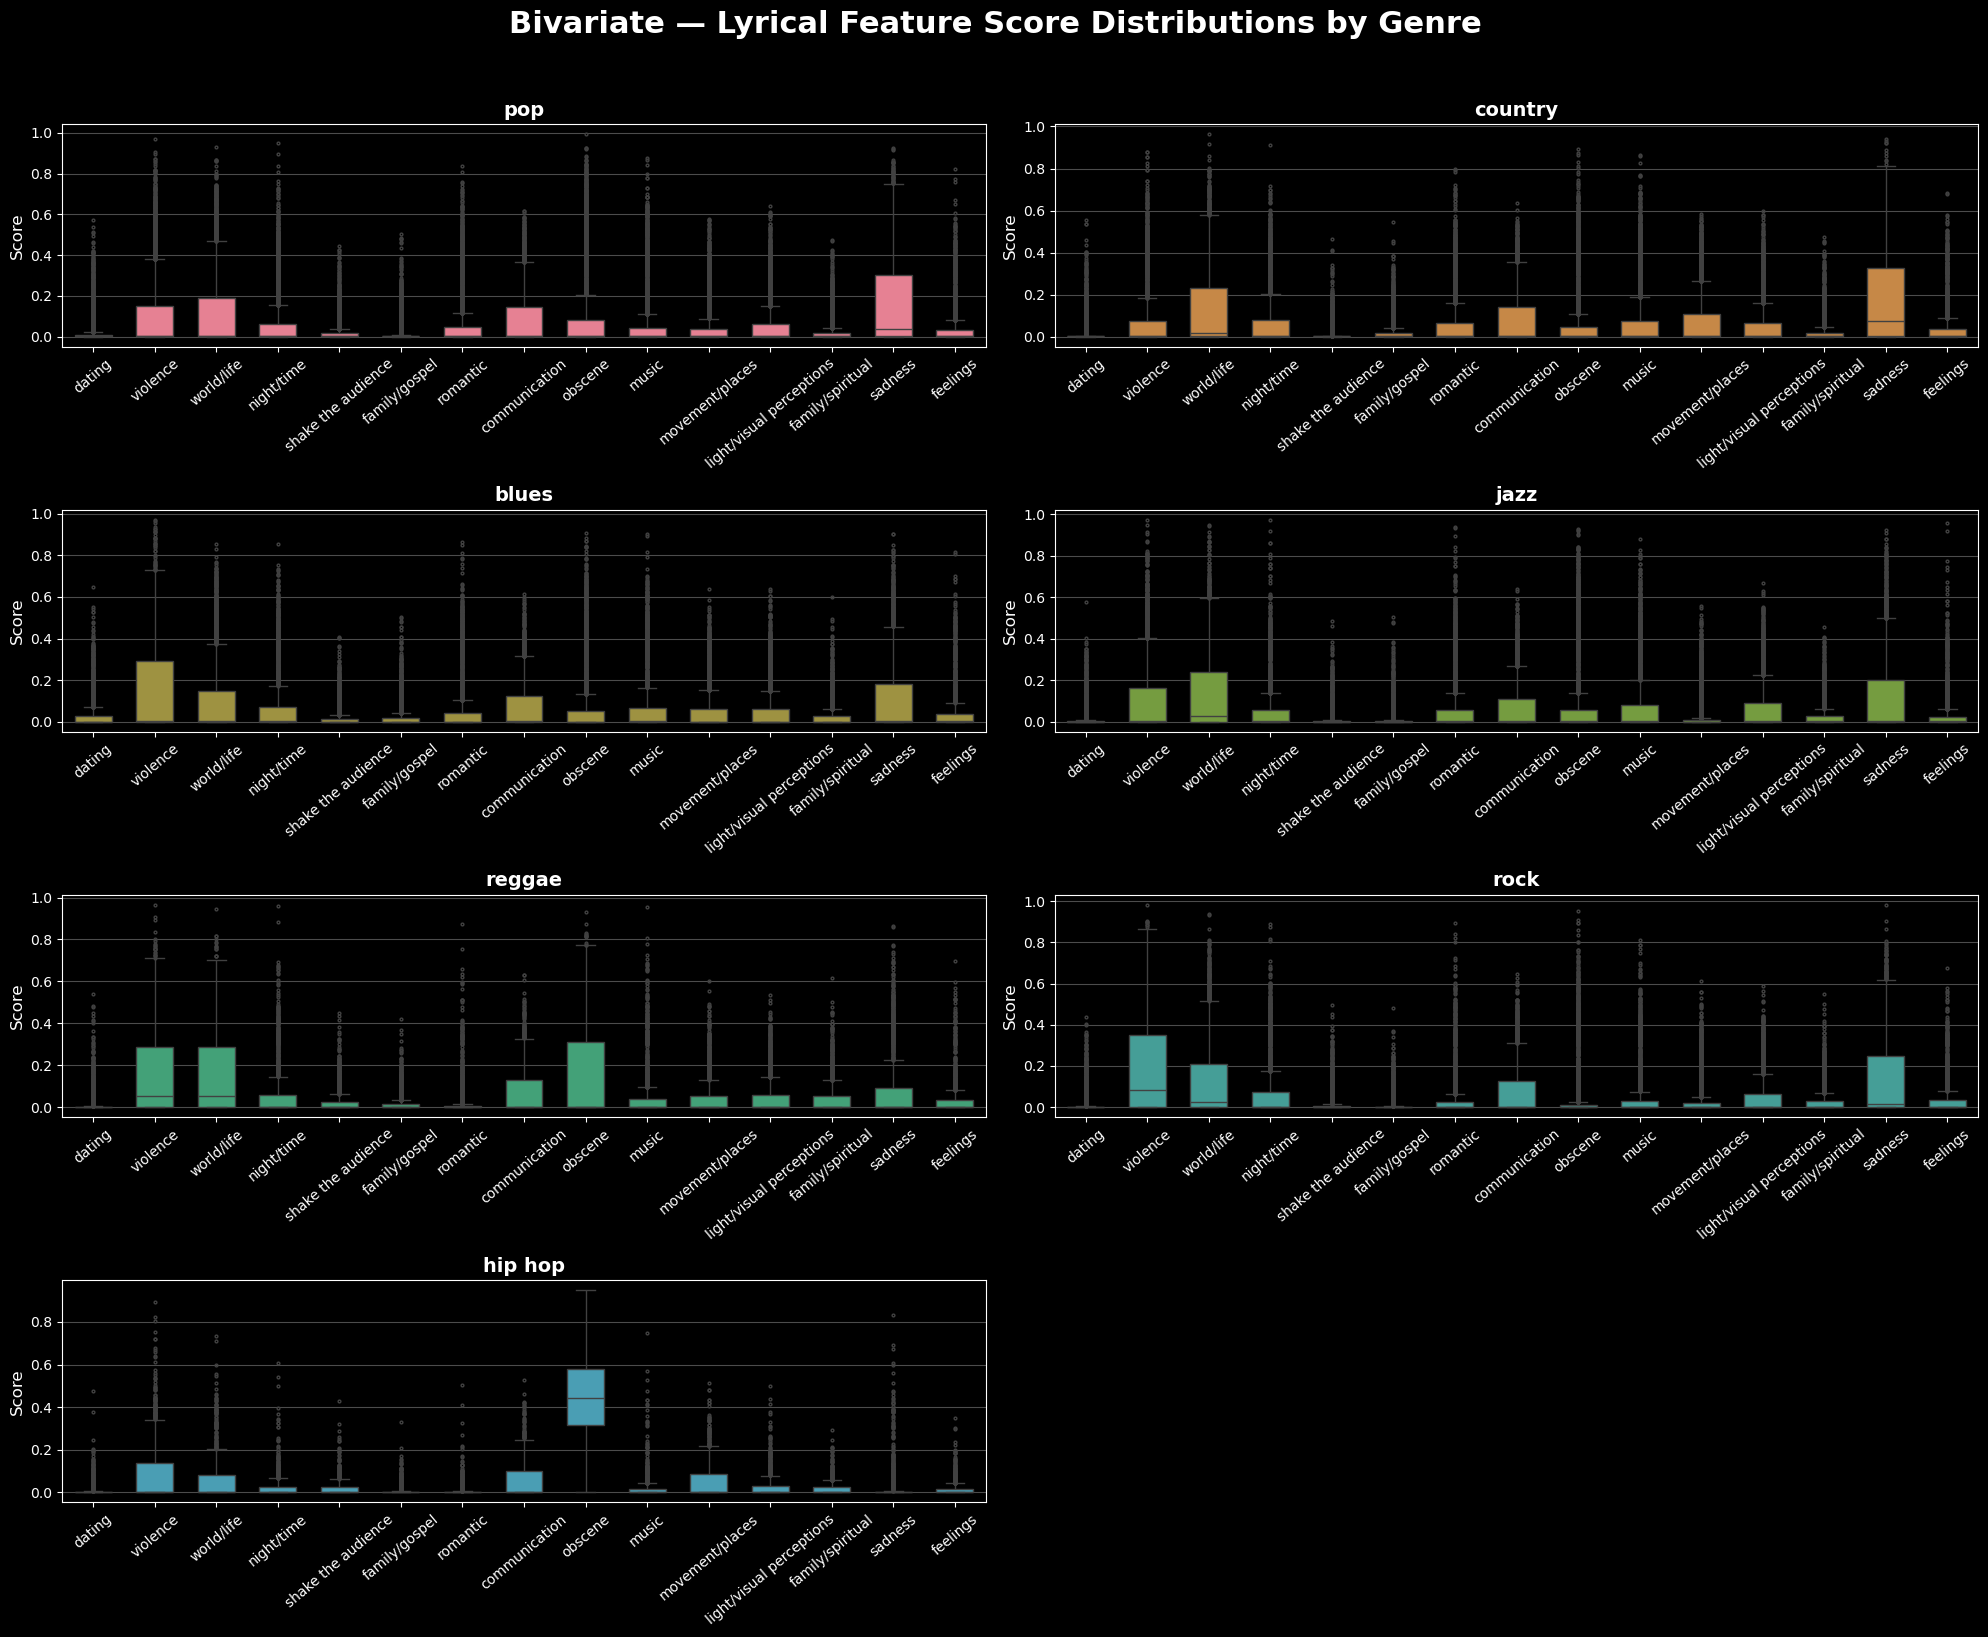

In [63]:
# Mean lyrical feature scores by genre
genres = df['genre'].unique().tolist()

fig, ax = plt.subplots(4, 2, figsize=(20, 16))
ax = ax.flatten()

for i, genre in enumerate(genres):
    sub = df[df['genre'] == genre]

    sns.boxplot(
        data=sub[lyrical_cols],
        ax=ax[i],
        color=PALETTE[i % len(PALETTE)],
        width=0.6,
        fliersize=2
    )

    ax[i].set_xticks(range(len(lyrical_cols)), lyrical_cols)
    ax[i].tick_params(axis='x', rotation=40, labelsize=10)

    ax[i].set_title(f"{genre}", fontweight="bold", fontsize=14)
    ax[i].set_ylabel("Score", fontsize=12)
    ax[i].grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(ax)):
    ax[j].set_visible(False)

plt.suptitle("Bivariate — Lyrical Feature Score Distributions by Genre",
             y=1.02, fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()


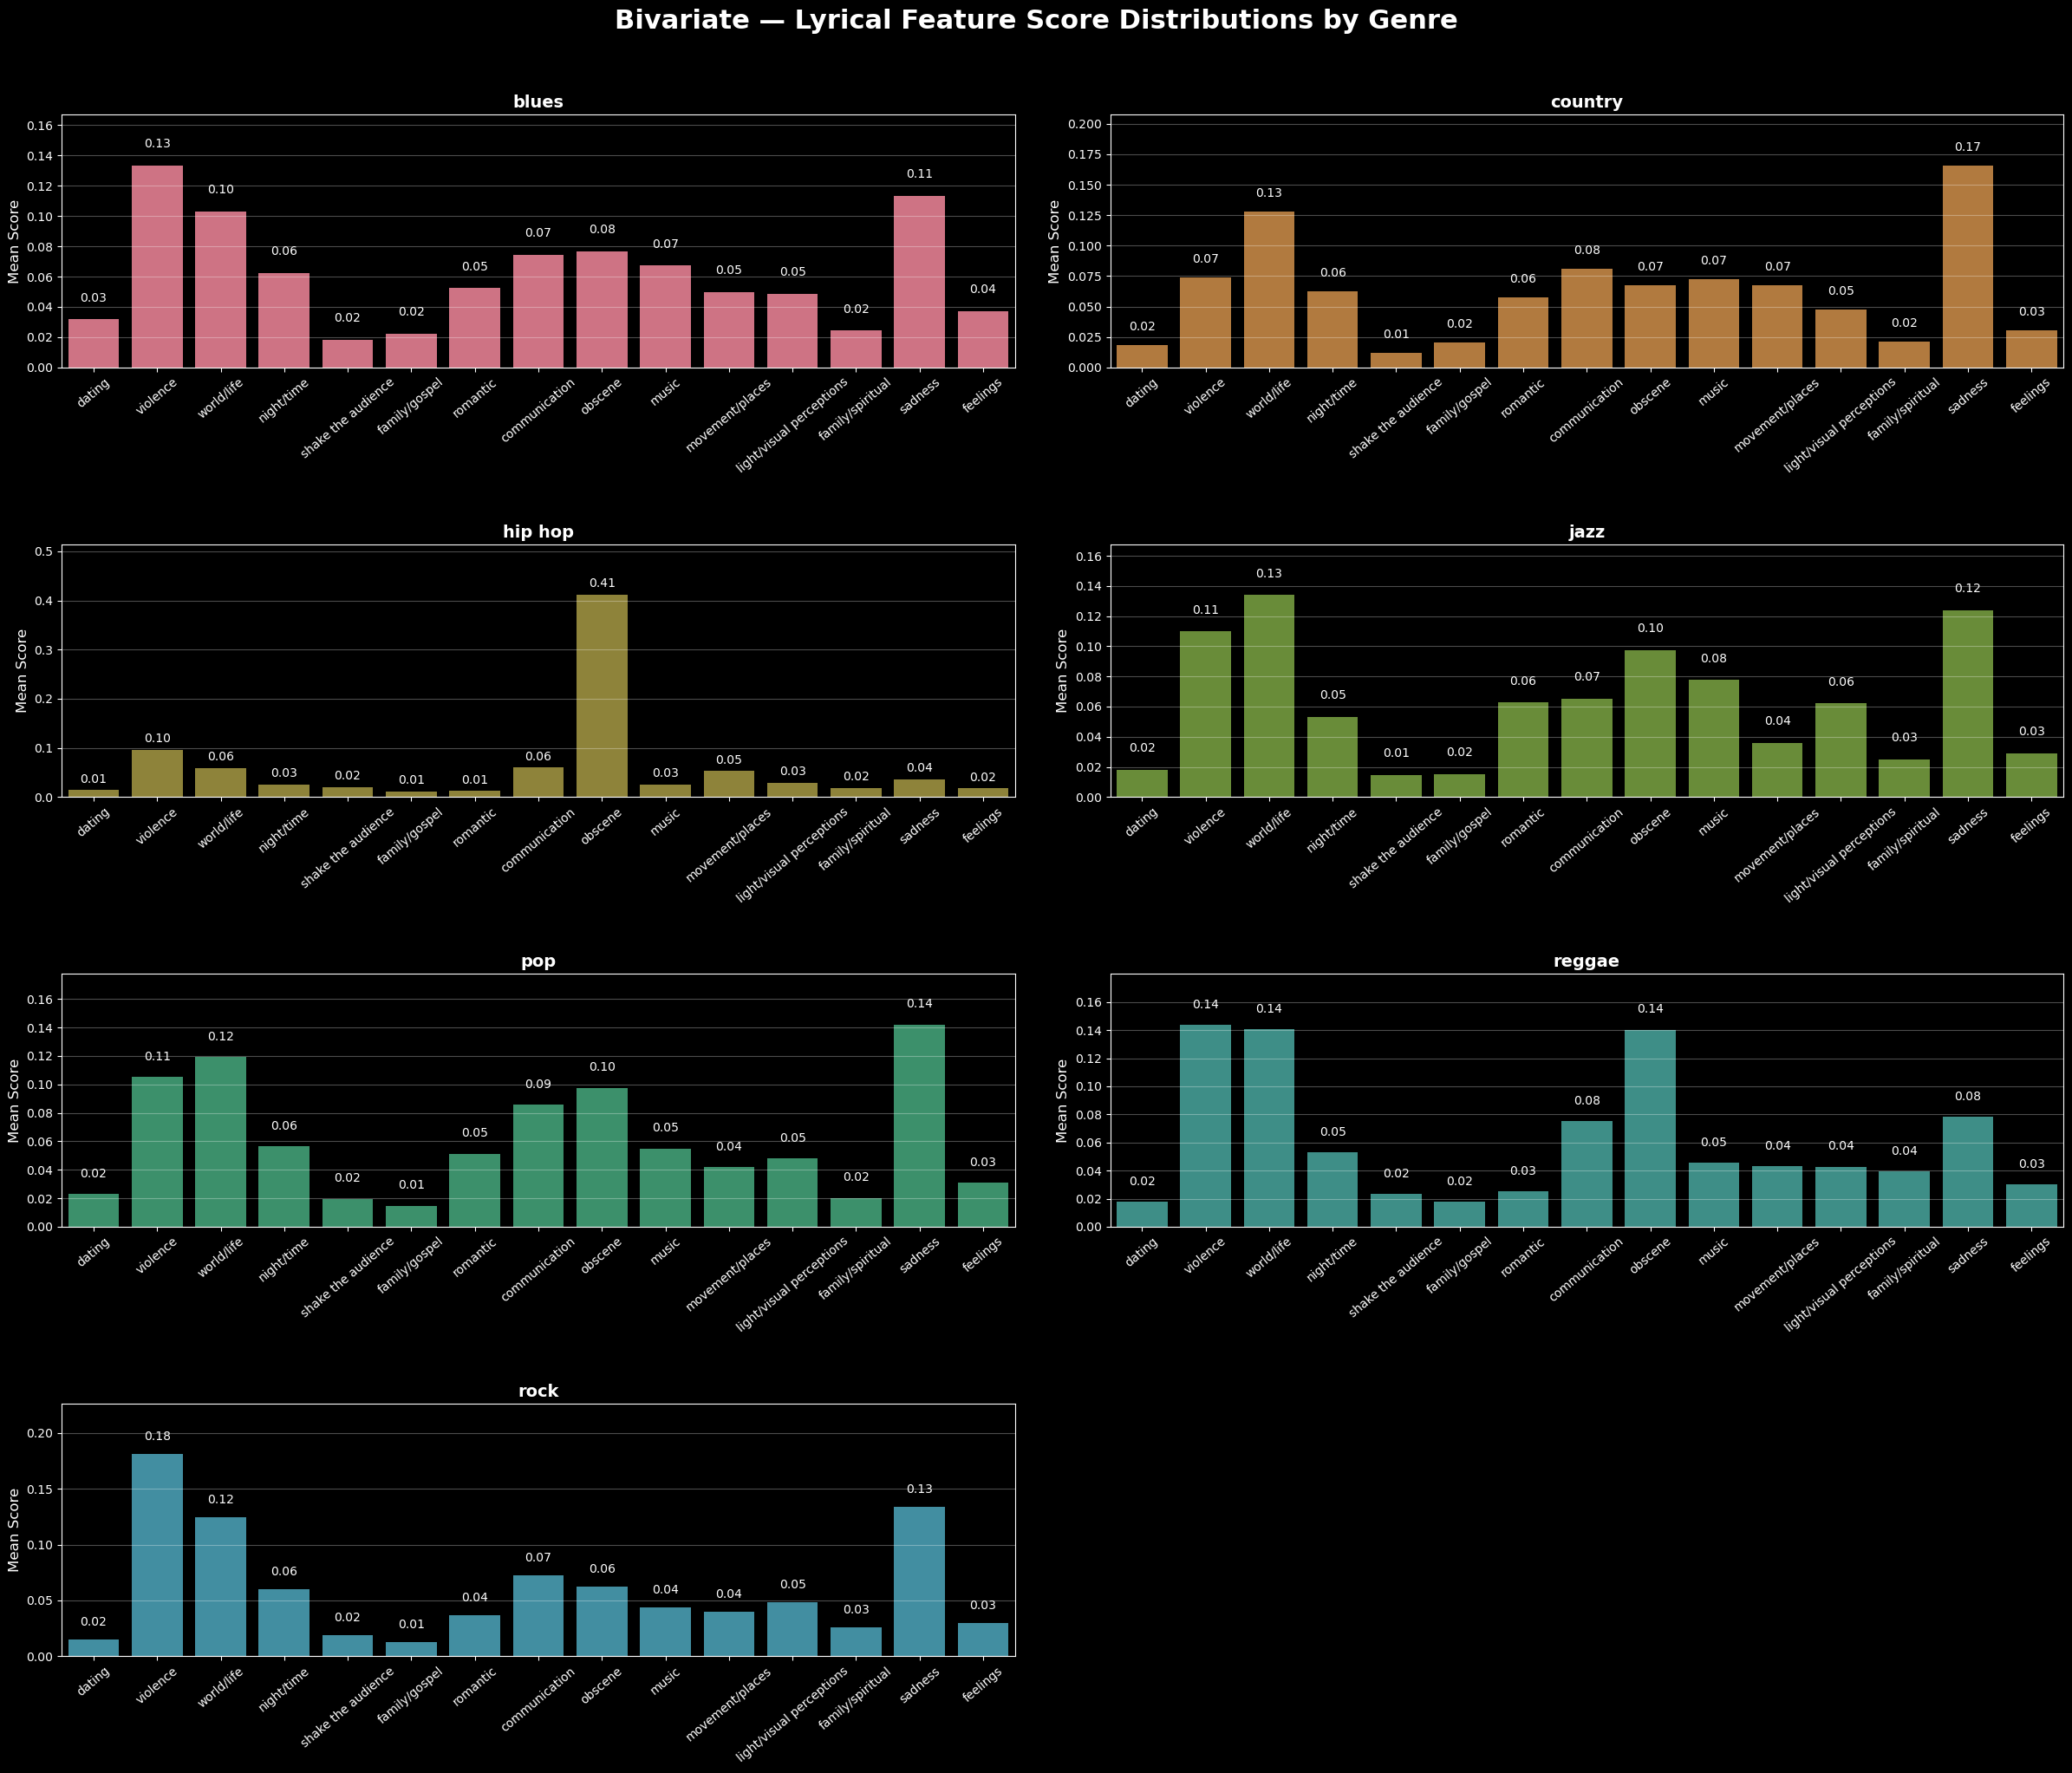

In [76]:
# Mean lyrical feature scores by genre
genre_means = df.groupby('genre')[lyrical_cols].mean()
genres = genre_means.index.tolist()

# Bigger figure for zoomed‑in look
fig, ax = plt.subplots(4, 2, figsize=(24, 20))
ax = ax.flatten()

for i, genre in enumerate(genres):
    means = genre_means.loc[genre]

    sns.barplot(
        x=lyrical_cols,
        y=means.values,
        ax=ax[i],
        color=PALETTE[i % len(PALETTE)],
        alpha=0.9
    )

    # Add value labels
    for x_pos, value in enumerate(means.values):
        ax[i].text(
            x_pos,
            value + 0.01,
            f"{value:.2f}",
            ha='center', va='bottom',
            fontsize=10
        )

    ax[i].set_title(f"{genre}", fontweight="bold", fontsize=14)
    ax[i].set_ylabel("Mean Score", fontsize=12)

    ax[i].set_xticks(range(len(lyrical_cols)), lyrical_cols)
    ax[i].tick_params(axis='x', labelrotation=40, labelsize=10)

    # Zoom effect
    ax[i].set_ylim(0, max(means.values) * 1.25)
    ax[i].set_xlim(-0.5, len(lyrical_cols) - 0.5)


    ax[i].grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(len(genres), len(ax)):
    ax[j].set_visible(False)

plt.suptitle("Bivariate — Lyrical Feature Score Distributions by Genre", 
             y=1.02, fontsize=22, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.7)
plt.show()


- Hiphop has the most starking difference is with obscene mean score (0.41) and the rest is less than 0.15. This is important for our model because it will likely cause KMeans to isolate hip hop into its own cluster.
- Top 4 genre-separating lyrical features are: obscene, sadness, violence, world/life 
- Rock has the highest violence mean (0.181) across all genre, which goes against common assumption *(that hiphop has more aggressive lyrics than rock)*
- Country has the highest sadness mean (0.166), higher than blues (0.113). This is somewhat surprising *(blues are typically built around themes of grief and hardship and country is usually more upbeat)*
- Reggae scores highest on world/life (0.141) and has the second highest obscene score (0.140) after hip hop — worth flagging
- Jazz and country both score highest on world/life (0.134 and 0.128). This suggests a reflective, narrative lyrical style shared across two very different genres *(this feature alone might not be enough to create a cluster between them)*

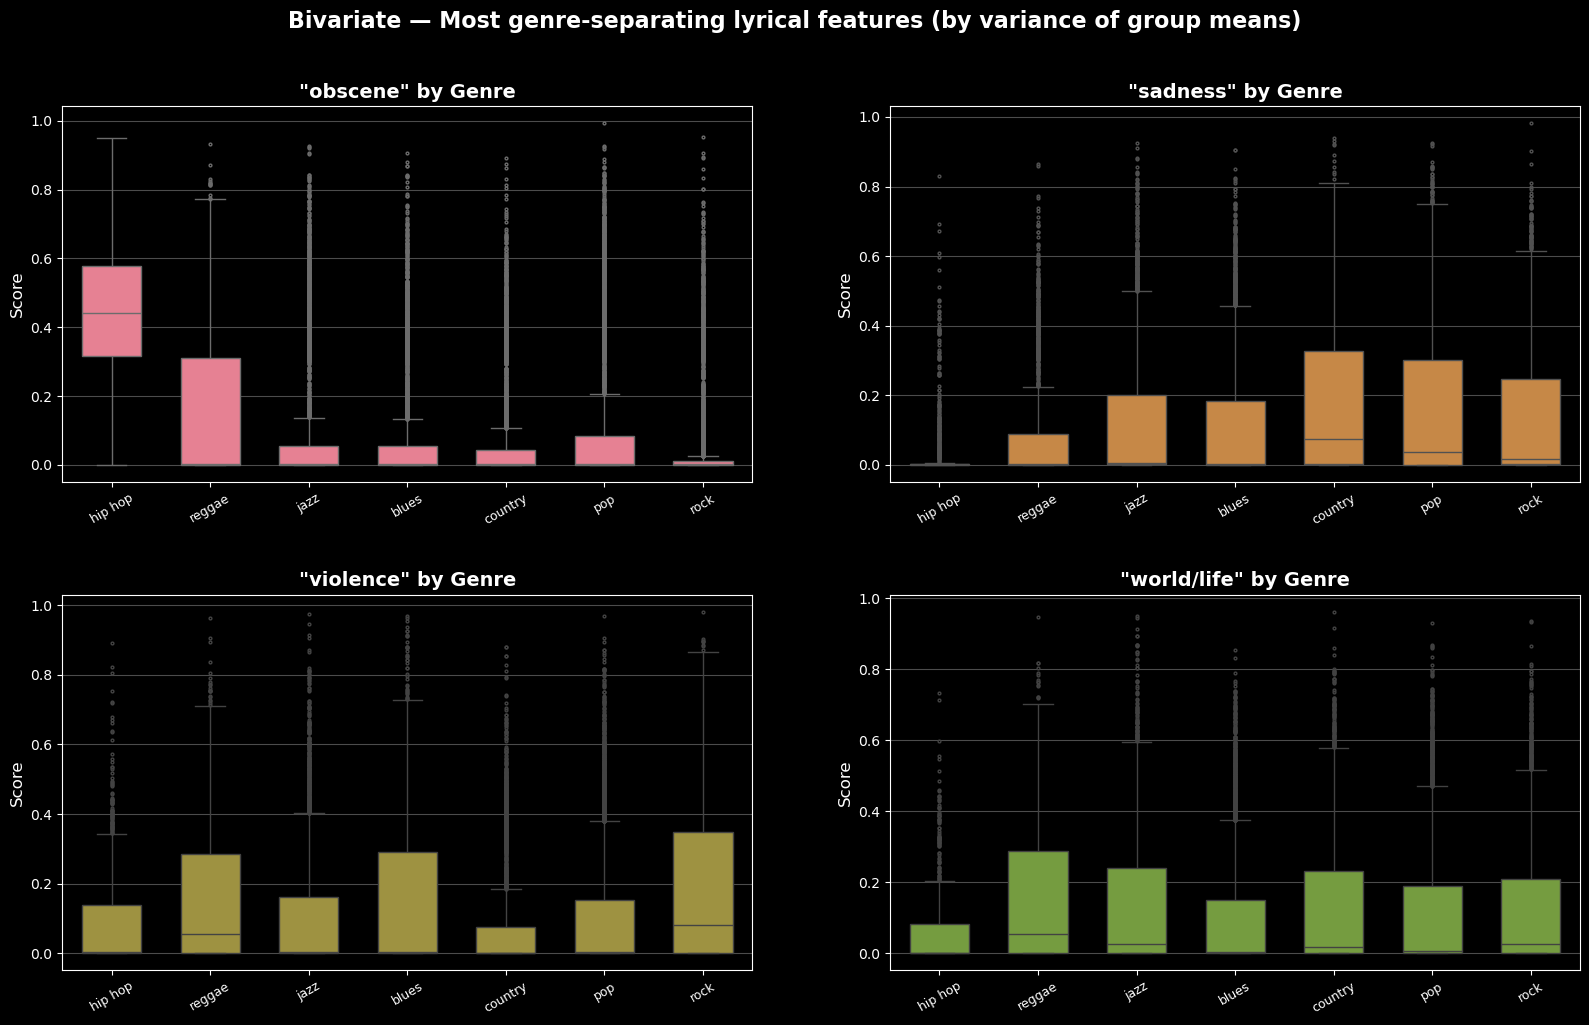

In [78]:
# Most genre-separating lyrical features
top_features = ['obscene', 'sadness', 'violence', 'world/life']

genre_order = (df.groupby('genre')['obscene'].median()
                 .sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(
        data=df,
        x='genre',
        y=col,
        order=genre_order,
        ax=axes[i],
        color=PALETTE[i % len(PALETTE)],
        width=0.6,
        fliersize=2
    )
    axes[i].tick_params(axis='x', rotation=30, labelsize=9)
    axes[i].set_title(f'"{col}" by Genre', fontweight='bold', fontsize=14)
    axes[i].set_ylabel('Score', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Bivariate — Most genre-separating lyrical features (by variance of group means)',
             y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()

- *obscene* is the clearest separator, outliers exist across all genres (meaning occasional explicit songs appear everywhere)

- songs vary wildly in their *sadness* score, knowing whether a song is country or pop doesn't reliably tell you how sad it is. Outliers stretch to 1.0 across most genres (sadness is never fully absent from any genre)

- *violence* medians are near 0 across all genres despite rock having the highest box. Heavy outliers reaching 0.9+ appear in nearly every genre (no single genre owns this feature cleanly)

- *world/life* shows the least separation of the four, boxes overlap heavily across all genres, and outliers are present but modest.

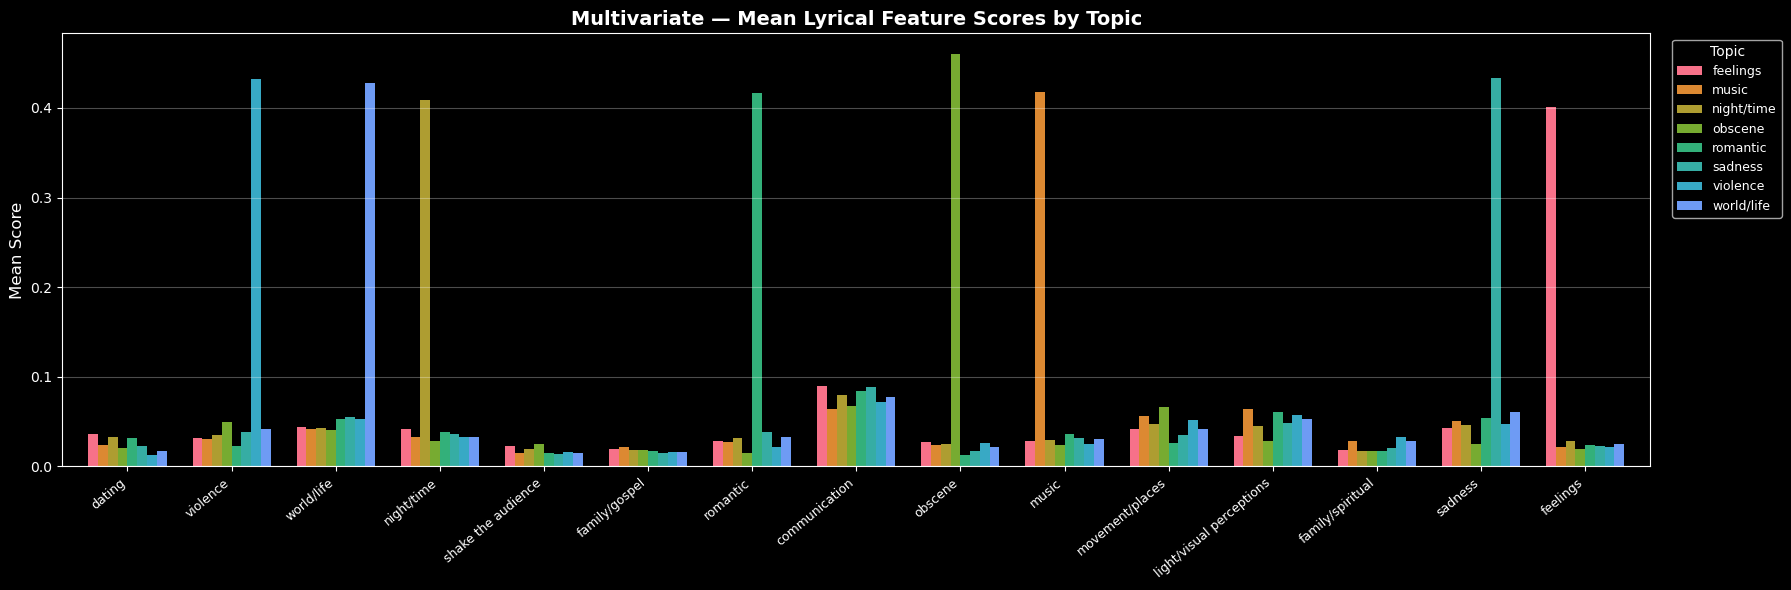

In [82]:
# Mean lyrical feature scores by topic
topic_means = df.groupby('topic')[lyrical_cols].mean()

fig, ax = plt.subplots(figsize=(18, 6))
topic_means.T.plot(kind='bar', ax=ax, color=PALETTE[:len(topic_means)],
                   edgecolor='none', width=0.75)
ax.set_xticks(range(len(lyrical_cols)))
ax.set_xticklabels(lyrical_cols, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean Score', fontsize=12)
ax.set_title('Bivariate — Mean Lyrical Feature Scores by Topic',
             fontsize=14, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This plot shows that the topic matches the highest lyrical score.
- Violence topic → highest violence score (0.432)
- Sadness topic → highest sadness score (0.433)
- and this applies to the rest of the topics.

Basically, the `topic` column is likely derived from the lyrical feature scores. The feature with the highest score determined the topic label.



## 4. Multivariate Analysis

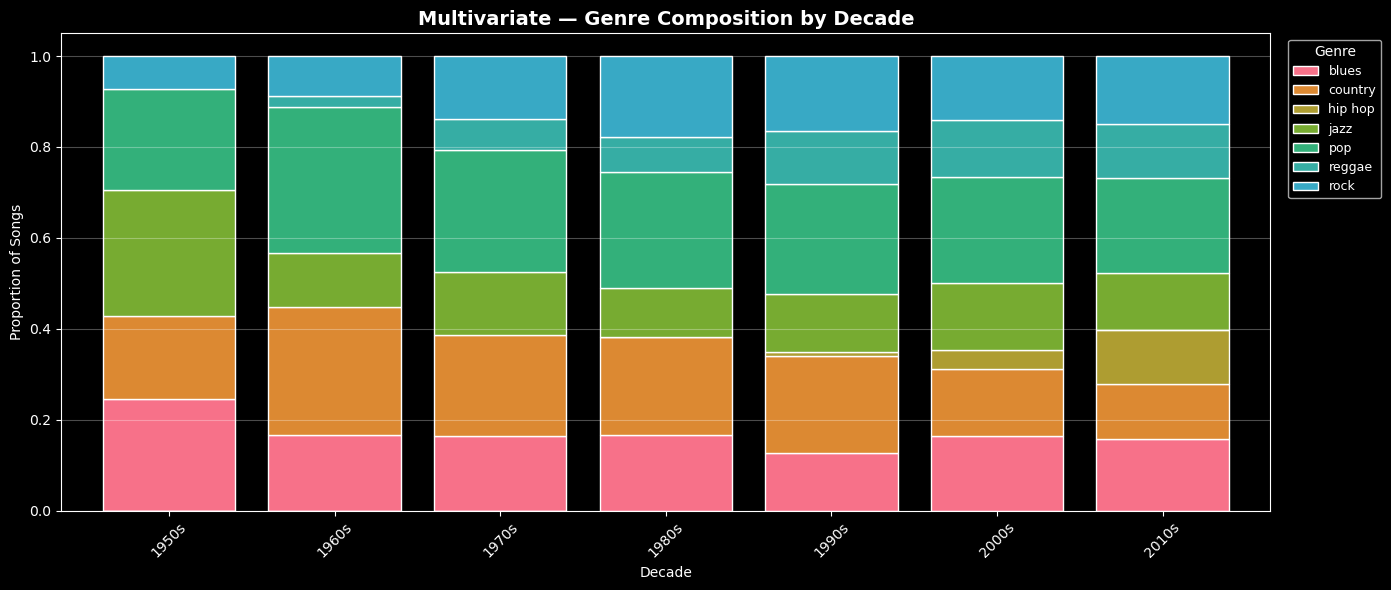

In [115]:
# would release_date be able help tell separation between genres?

df['decade'] = (df['release_date'] // 10) * 10
decade_genre = df.groupby(['decade','genre']).size().unstack(fill_value=0)
decade_genre_pct = decade_genre.div(decade_genre.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
decade_genre_pct.plot(kind='bar', stacked=True, ax=ax, 
                      color=PALETTE[:len(decade_genre_pct.columns)], edgecolor='white', width=0.8)


ax.set_title('Multivariate — Genre Composition by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Proportion of Songs')
ax.set_xticklabels([f'{int(d)}s' for d in decade_genre_pct.index], rotation=45)
ax.legend(title='Genre', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()


- This plot matters because if clusters end up separated by decade rather than lyrical content, our model would just be detecting time periods, not meaningful lyrical patterns.
- Blues and jazz dominated the 1950s but steadily go down till the 1990s and pick up a little by 2000s.
- Hiphop doesn't show up until around 1990s *(meaning the age feature and hip hop genre are closely tied, which could introduce bias into our clusters)*
- Country and pop have remained consistently present across all decades, suggesting their lyrical features are stable over time and less tied to any era.

<Figure size 1500x1000 with 0 Axes>

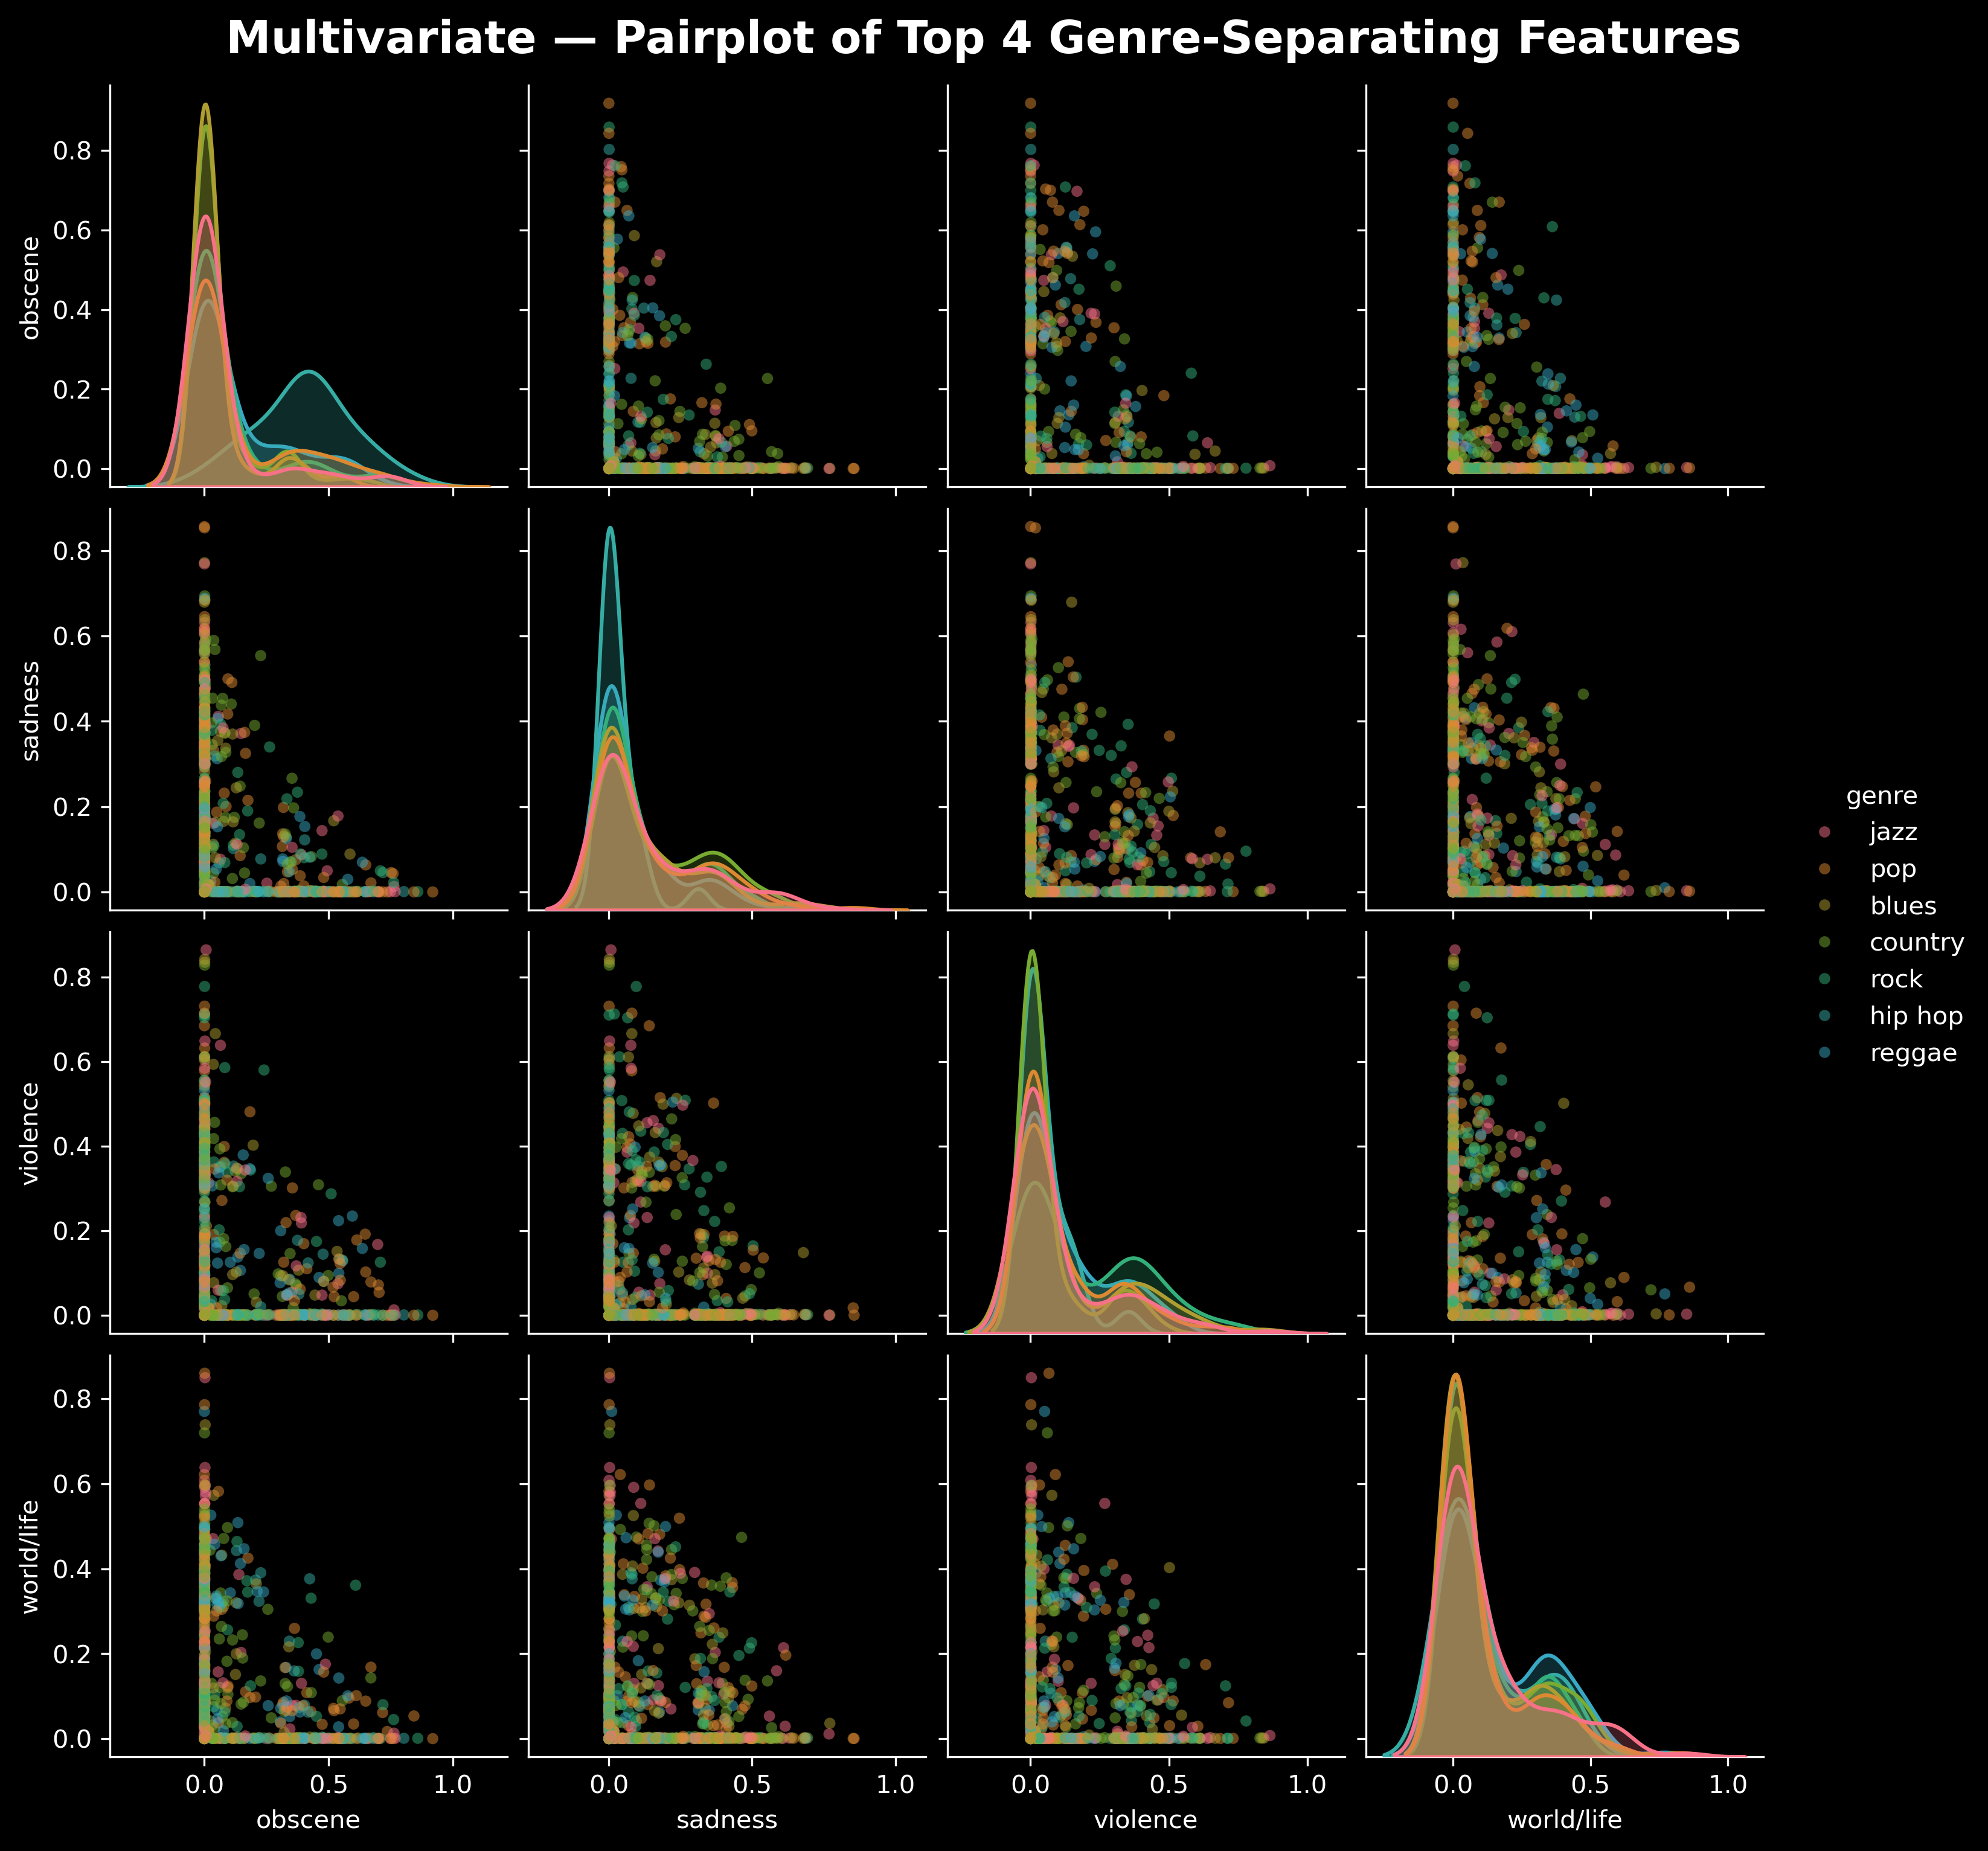

In [118]:
# From bivariate analysis, we identified the top 4 genre-separating features
# To dig deeper, lets use pairplot to look at multiple features at the same time 
# and see how they relate to each other across genres.

top_features = ['obscene', 'sadness', 'violence', 'world/life']

# Subset for faster output
pair_df = df[top_features + ['genre']].sample(1000, random_state=42)


plt.figure(figsize=(15,10))

# Pairplot
pair_grid = sns.pairplot(
    pair_df,
    vars=top_features,
    hue='genre',
    diag_kind='kde',
    palette=PALETTE[:len(pair_df['genre'].unique())],
    plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'none'},
    diag_kws={'linewidth': 1.5, 'common_norm': False}
)

pair_grid.figure.set_dpi(300)

pair_grid.figure.suptitle(
    "Multivariate — Pairplot of Top 4 Genre-Separating Features",
    y=1.02,
    fontsize=18,
    fontweight='bold'
)

plt.show()


- `obscene` (top-left) — hip hop has a clearly distinct distribution shifted to the right, while the other genres are near 0, confirming it's the strongest separator.
- `obscene` vs `sadness` (row 2, col 1) — genres cluster tightly in the bottom-left corner with no clear separation *(meaning high obscene and high sadness rarely co-occur in the same song)*
- `violence` (row 3, col 3) — all genres overlap heavily near 0, confirming violence alone is not enough to separate genres cleanly.
- `world/life` (bottom-right) — all genre distributions are nearly identical, reinforcing that this feature contributes the least separation of the four.

Overall, across all scatter plots, points from different genres mix together in the bottom-left corner, suggesting that no single pair of these features creates clean boundaries between genres which is exactly why we need a clustering algorithm to find structure across all features simultaneously.

## 5. Hypothesis

Based on the EDA above, we find that:

- **Sadness and violence** are the two most common lyrical topics, together accounting for ~42% of songs.
- **Pop** is the most represented genre; **hiphop** is severely underrepresented — this may influence clusters
- Most lyrical score distributions are **heavily right-skewed** (most songs score near 0 on most features)
- The strongest correlation is with `len` and `obscene` (r=0.44) - longer songs tend to score higher on obscene content, consistent with hip hop / rap styles. But would this help us actually reach our goal of clustering songs based on lyrical content? Doesn't seem like it.
<br>
<br>

We hypothesize that K‑Means will identify approximately four clusters. These clusters likely correspond to the dominant lyrical‑feature patterns we observed:
1. High-obscene → hiphop songs
2. High-sadness → country/pop 
3. Violence → rock/blues
4. World/life → reggae

These hypotheses will be tested and refined in Notebook 3 after preprocessing.